# TP 2 - Segmentation clients RFM

**Projet :** segmentation de clients e-commerce à partir du jeu de données réel **UCI Online Retail II**.  
**Objectif métier :** transformer un historique de transactions bruité en segments actionnables pour personnaliser les campagnes marketing, prioriser la fidélisation et limiter l'attrition.

Ce notebook suit les cinq attendus du sujet :

1. nettoyage des transactions ;
2. construction et transformation des variables RFM ;
3. choix argumenté du nombre de segments ;
4. caractérisation, nommage et recommandations ;
5. discussion critique et éthique.

## Membres du groupe

- AKAYA Eniwinéwé Henri
- ALKISSANKDEI T. Djamal
- BLAISE Mouné Tchoubou
- LARE V. Donné
- METO Kemi Gédéon
- OPEKOU-DOUDOE Christian
- TORA Dkawlma Emmanuel


## 0. Préparation

Les choix techniques ci-dessous visent la reproductibilité : chemins centralisés, graine aléatoire fixe, affichage compact et sauvegarde des livrables intermédiaires dans `outputs/`.

In [ ]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import (
    adjusted_rand_score, silhouette_score,
    calinski_harabasz_score, davies_bouldin_score,
)
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
DATA_PATH = Path("data/online_retail_II.xlsx")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid", palette="Set2")

## 1. Chargement des données

Le fichier UCI contient deux feuilles correspondant à deux années commerciales. On les concatène dès le départ pour éviter une segmentation partielle.

In [26]:
# Lecture des deux feuilles Excel et ajout d'une colonne de traçabilité.
excel_file = pd.ExcelFile(DATA_PATH)
frames = []

for sheet_name in excel_file.sheet_names:
    sheet = pd.read_excel(DATA_PATH, sheet_name=sheet_name)
    sheet["SourceSheet"] = sheet_name
    frames.append(sheet)

raw = pd.concat(frames, ignore_index=True)

print(f"Feuilles chargées : {excel_file.sheet_names}")
print(f"Nombre de lignes brutes : {raw.shape[0]:,}")
print(f"Nombre de colonnes brutes : {raw.shape[1]}")
raw.head()

Feuilles chargées : ['Year 2009-2010', 'Year 2010-2011']
Nombre de lignes brutes : 1,067,371
Nombre de colonnes brutes : 9


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,SourceSheet
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom,Year 2009-2010
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,Year 2009-2010
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,Year 2009-2010
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom,Year 2009-2010
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom,Year 2009-2010


In [27]:
# Les noms de colonnes de la version Online Retail II diffèrent légèrement du sujet.
# On les harmonise vers un vocabulaire clair et stable pour le reste du notebook.
rename_map = {
    "Invoice": "InvoiceNo",
    "Price": "UnitPrice",
    "Customer ID": "CustomerID",
}
transactions = raw.rename(columns=rename_map).copy()

transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   InvoiceNo    1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   UnitPrice    1067371 non-null  float64       
 6   CustomerID   824364 non-null   float64       
 7   Country      1067371 non-null  object        
 8   SourceSheet  1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 73.3+ MB


In [28]:
# Premier diagnostic : valeurs manquantes, doublons et période couverte.
diagnostic_initial = pd.DataFrame({
    "type": transactions.dtypes.astype(str),
    "valeurs_manquantes": transactions.isna().sum(),
    "pct_manquant": transactions.isna().mean().mul(100),
    "valeurs_uniques": transactions.nunique(dropna=True),
})

display(diagnostic_initial)

print("Période couverte :", transactions["InvoiceDate"].min(), "->", transactions["InvoiceDate"].max())
print("Doublons exacts :", transactions.duplicated().sum())

,type,valeurs_manquantes,pct_manquant,valeurs_uniques
InvoiceNo,object,0,0.00,53628
StockCode,object,0,0.00,5305
Description,object,4382,0.41,5698
Quantity,int64,0,0.00,1057
InvoiceDate,datetime64[ns],0,0.00,47635
UnitPrice,float64,0,0.00,2807
CustomerID,float64,243007,22.77,5942
Country,object,0,0.00,43
SourceSheet,object,0,0.00,2


Période couverte : 2009-12-01 07:45:00 -> 2011-12-09 12:50:00
Doublons exacts : 12133


## 2. Partie 1 - Nettoyage des transactions

Règles retenues et justification :

- **Clients sans identifiant supprimés** : impossible de construire une récence, fréquence ou valeur monétaire par client sans `CustomerID`.
- **Annulations/retours exclus du clustering principal** : les factures commençant par `C` et les quantités négatives représentent des retours ou annulations. Elles sont conservées dans les indicateurs de contrôle, mais on segmente d'abord le comportement d'achat positif.
- **Prix et quantités non positifs exclus** : ils ne décrivent pas un achat exploitable pour le montant dépensé.
- **Doublons exacts supprimés** : ils gonflent artificiellement fréquence et montant.
- **Valeurs extrêmes plafonnées plus tard au niveau client** : les gros clients existent réellement en B2B ; les supprimer trop tôt ferait perdre un signal métier. On limite leur influence après agrégation via une winsorisation douce.

In [29]:
# Indicateurs de qualité avant filtrage : ils documentent l'impact des règles de nettoyage.
transactions["InvoiceNo"] = transactions["InvoiceNo"].astype(str)
transactions["CustomerID"] = pd.to_numeric(transactions["CustomerID"], errors="coerce")
transactions["Quantity"] = pd.to_numeric(transactions["Quantity"], errors="coerce")
transactions["UnitPrice"] = pd.to_numeric(transactions["UnitPrice"], errors="coerce")
transactions["InvoiceDate"] = pd.to_datetime(transactions["InvoiceDate"], errors="coerce")
transactions["Description"] = transactions["Description"].astype("string").str.strip()
transactions["Country"] = transactions["Country"].astype("string").str.strip()

transactions["is_cancelled_invoice"] = transactions["InvoiceNo"].str.upper().str.startswith("C")
transactions["is_return_line"] = transactions["Quantity"] < 0
transactions["LineAmount"] = transactions["Quantity"] * transactions["UnitPrice"]

cleaning_audit = pd.Series({
    "lignes_brutes": len(transactions),
    "clients_distincts_bruts": transactions["CustomerID"].nunique(dropna=True),
    "factures_annulees": transactions["is_cancelled_invoice"].sum(),
    "lignes_quantite_negative": transactions["is_return_line"].sum(),
    "customer_id_manquant": transactions["CustomerID"].isna().sum(),
    "prix_non_positif": (transactions["UnitPrice"] <= 0).sum(),
    "quantite_non_positive": (transactions["Quantity"] <= 0).sum(),
    "doublons_exacts": transactions.duplicated().sum(),
})
cleaning_audit.to_frame("valeur")

,valeur
lignes_brutes,1067371
clients_distincts_bruts,5942
factures_annulees,19494
lignes_quantite_negative,22950
customer_id_manquant,243007
prix_non_positif,6207
quantite_non_positive,22950
doublons_exacts,12133


In [30]:
# Nettoyage principal : seules les lignes d'achat positives identifiables sont gardées.
clean = (
    transactions
    .drop_duplicates()
    .loc[lambda d: d["CustomerID"].notna()]
    .loc[lambda d: d["InvoiceDate"].notna()]
    .loc[lambda d: ~d["is_cancelled_invoice"]]
    .loc[lambda d: d["Quantity"] > 0]
    .loc[lambda d: d["UnitPrice"] > 0]
    .copy()
)

clean["CustomerID"] = clean["CustomerID"].astype(int).astype(str)
clean["LineAmount"] = clean["Quantity"] * clean["UnitPrice"]

print(f"Lignes conservées : {len(clean):,} ({len(clean) / len(transactions):.1%} des lignes brutes)")
print(f"Clients conservés : {clean['CustomerID'].nunique():,}")
print(f"Chiffre d'affaires positif : £{clean['LineAmount'].sum():,.0f}")
clean.head()

Lignes conservées : 793,609 (74.4% des lignes brutes)
Clients conservés : 5,878
Chiffre d'affaires positif : £17,685,461


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,SourceSheet,is_cancelled_invoice,is_return_line,LineAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,Year 2009-2010,False,False,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,Year 2009-2010,False,False,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,Year 2009-2010,False,False,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,Year 2009-2010,False,False,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,Year 2009-2010,False,False,30.00


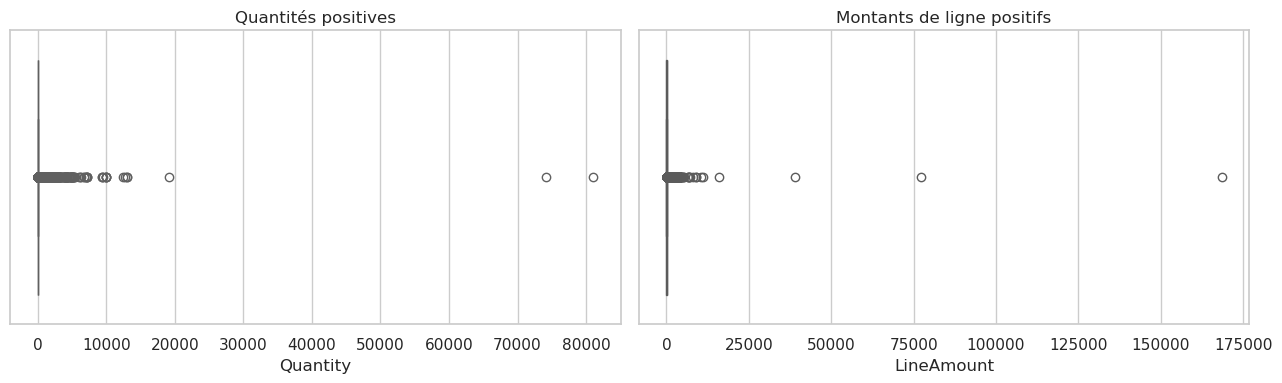

,count,mean,std,min,1%,5%,50%,95%,99%,max
Quantity,793609.00,13.45,144.69,1.00,1.00,1.00,6.00,36.00,140.00,80995.00
UnitPrice,793609.00,3.22,29.42,0.00,0.29,0.42,1.95,8.50,14.95,10953.50
LineAmount,793609.00,22.28,225.71,0.00,0.60,1.25,12.48,67.50,203.52,168469.60


In [31]:
# Contrôle des valeurs extrêmes transactionnelles.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(x=clean["Quantity"], ax=axes[0], color="#5DADE2")
axes[0].set_title("Quantités positives")
sns.boxplot(x=clean["LineAmount"], ax=axes[1], color="#58D68D")
axes[1].set_title("Montants de ligne positifs")
plt.tight_layout()
plt.show()

clean[["Quantity", "UnitPrice", "LineAmount"]].describe(percentiles=[.01, .05, .5, .95, .99]).T

## 3. Partie 2 - Construction des features RFM

La date de référence est fixée au lendemain de la dernière transaction observée. C'est plus réaliste qu'une date système, car le dataset est historique.

Définitions :

- **Recency** : nombre de jours depuis le dernier achat ; plus petit = client plus récent.
- **Frequency** : nombre de factures distinctes positives ; plus grand = client plus actif.
- **Monetary** : somme des montants positifs ; plus grand = client plus rentable.

In [32]:
analysis_date = clean["InvoiceDate"].max() + pd.Timedelta(days=1)
print("Date de référence RFM :", analysis_date.date())

rfm = (
    clean.groupby("CustomerID")
    .agg(
        Recency=("InvoiceDate", lambda s: (analysis_date - s.max()).days),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("LineAmount", "sum"),
        FirstPurchase=("InvoiceDate", "min"),
        LastPurchase=("InvoiceDate", "max"),
        CountryMode=("Country", lambda s: s.mode().iat[0] if not s.mode().empty else pd.NA),
    )
    .reset_index()
)

rfm["CustomerTenureDays"] = (analysis_date - rfm["FirstPurchase"]).dt.days
rfm["AverageBasket"] = rfm["Monetary"] / rfm["Frequency"]

print(f"Clients RFM : {len(rfm):,}")
rfm.head()

Date de référence RFM : 2011-12-10
Clients RFM : 5,878


,CustomerID,Recency,Frequency,Monetary,FirstPurchase,LastPurchase,CountryMode,CustomerTenureDays,AverageBasket
0,12346,326,12,77556.46,2009-12-14 08:34:00,2011-01-18 10:01:00,United Kingdom,726,6463.04
1,12347,2,8,5633.32,2010-10-31 14:20:00,2011-12-07 15:52:00,Iceland,404,704.16
2,12348,75,5,2019.40,2010-09-27 14:59:00,2011-09-25 13:13:00,Finland,438,403.88
3,12349,19,4,4428.69,2010-04-29 13:20:00,2011-11-21 09:51:00,Italy,589,1107.17
4,12350,310,1,334.40,2011-02-02 16:01:00,2011-02-02 16:01:00,Norway,310,334.40


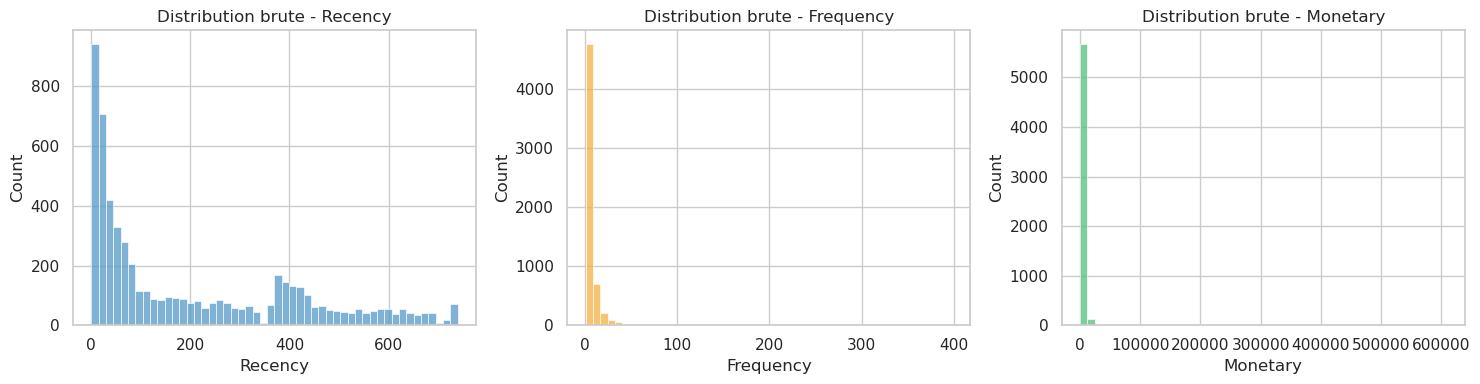

,count,mean,std,min,5%,25%,50%,75%,95%,99%,max
Recency,5878.00,201.33,209.34,1.00,4.00,26.00,96.00,380.00,625.00,726.00,739.00
Frequency,5878.00,6.29,13.01,1.00,1.00,1.00,3.00,7.00,21.00,46.00,398.00
Monetary,5878.00,3008.75,14731.92,2.95,112.53,345.12,887.39,2298.01,9504.78,29710.55,608821.65
AverageBasket,5878.00,389.99,1215.01,2.95,89.69,179.45,283.61,419.67,914.71,1994.99,84236.25


In [33]:
# Les distributions RFM sont généralement asymétriques : quelques clients B2B concentrent une forte valeur.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color in zip(axes, ["Recency", "Frequency", "Monetary"], ["#5499C7", "#F5B041", "#52BE80"]):
    sns.histplot(rfm[col], bins=50, ax=ax, color=color)
    ax.set_title(f"Distribution brute - {col}")
plt.tight_layout()
plt.show()

rfm[["Recency", "Frequency", "Monetary", "AverageBasket"]].describe(percentiles=[.05, .25, .5, .75, .95, .99]).T

In [34]:
# Winsorisation douce au 99e percentile : on limite l'influence des valeurs extrêmes
# sans supprimer les gros clients, qui sont importants commercialement.
rfm_model = rfm[["CustomerID", "Recency", "Frequency", "Monetary"]].copy()
for col in ["Recency", "Frequency", "Monetary"]:
    upper = rfm_model[col].quantile(0.99)
    rfm_model[f"{col}_Capped"] = rfm_model[col].clip(upper=upper)

# log1p réduit l'asymétrie et rend les distances euclidiennes plus comparables.
for col in ["Recency", "Frequency", "Monetary"]:
    rfm_model[f"log_{col}"] = np.log1p(rfm_model[f"{col}_Capped"])

feature_cols = ["log_Recency", "log_Frequency", "log_Monetary"]
scaler = StandardScaler()
X = scaler.fit_transform(rfm_model[feature_cols])

rfm_model[feature_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
log_Recency,5878.00,4.45,1.56,0.69,3.30,4.57,5.94,6.59
log_Frequency,5878.00,1.54,0.79,0.69,0.69,1.39,2.08,3.85
log_Monetary,5878.00,6.82,1.36,1.37,5.85,6.79,7.74,10.30


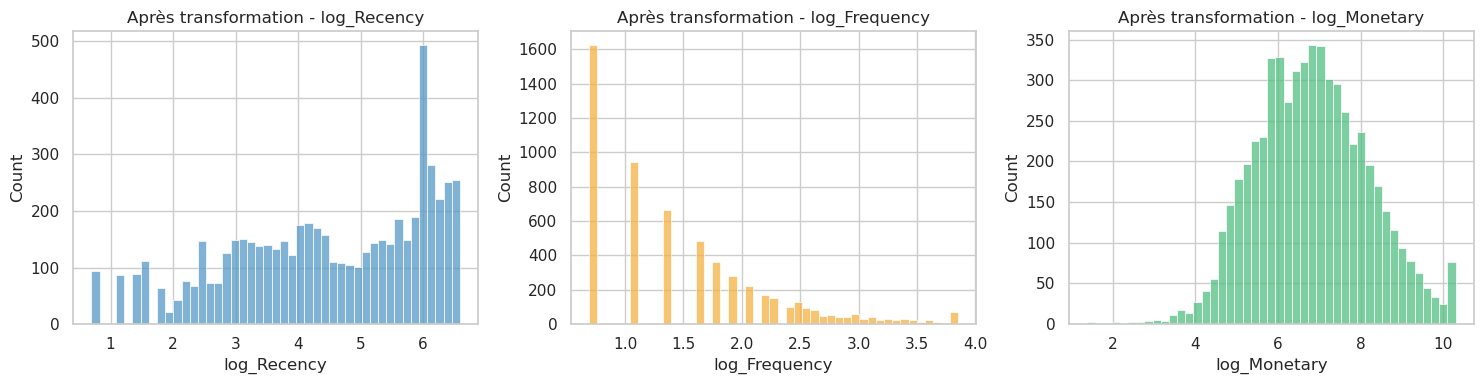

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color in zip(axes, feature_cols, ["#5499C7", "#F5B041", "#52BE80"]):
    sns.histplot(rfm_model[col], bins=45, ax=ax, color=color)
    ax.set_title(f"Après transformation - {col}")
plt.tight_layout()
plt.show()

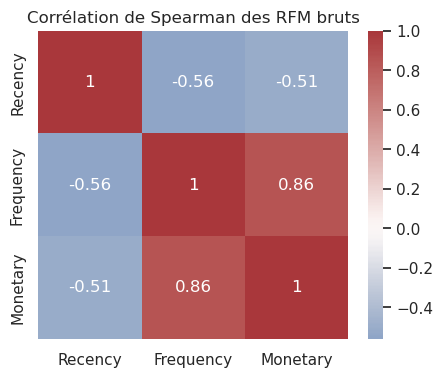

In [36]:
# Vérification de la corrélation : utile pour discuter la redondance Fréquence/Montant.
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(rfm[["Recency", "Frequency", "Monetary"]].corr(method="spearman"), annot=True, cmap="vlag", center=0, ax=ax)
ax.set_title("Corrélation de Spearman des RFM bruts")
plt.show()

## 4. Partie 3 - Évaluation statistique et choix commercial de k

K-means est appliqué aux RFM plafonnés au 99e percentile, transformés par
`log1p`, puis standardisés. Nous comparons tous les `k` de 2 à 8 avec le même
prétraitement, la même graine et le même nombre d'initialisations.

| Critère | Lecture |
| --- | --- |
| Inertie et coude | Repérer où le gain de compacité ralentit ; l'inertie seule diminue avec k |
| Silhouette | Maximiser la séparation et la cohésion moyennes |
| Calinski-Harabasz | Maximiser le rapport de dispersion entre groupes / dans les groupes |
| Davies-Bouldin | Minimiser la similarité moyenne avec le groupe le plus proche |
| Stabilité ARI | Comparer les partitions entre dix graines, sans comparer directement leurs numéros |
| Taille et profils des groupes | Vérifier la faisabilité et la différence des actions marketing |

Source : [documentation scikit-learn sur l'évaluation du clustering](https://scikit-learn.org/stable/modules/clustering.html#clustering-performance-evaluation).
Ces indices internes partagent des hypothèses géométriques et ne sont pas des
preuves indépendantes de valeur commerciale. La stabilité entre graines ne
mesure pas la stabilité dans le temps ou sur de nouveaux échantillons.

Nous affichons le meilleur k de chaque critère et un **compromis statistique
indicatif** : moyenne des rangs silhouette, Calinski-Harabasz et Davies-Bouldin,
à poids égaux (égalité départagée en faveur du plus petit k). Ce classement
est une règle descriptive, pas un optimum universel. Le coude, la stabilité
et la lecture métier sont examinés séparément.

Le **choix commercial final reste k = 5**, même si les critères statistiques
préfèrent 2, 4 ou une autre valeur. Nous devons rendre visible le coût de ce
choix et vérifier ce que le cinquième groupe apporte aux campagnes.

In [37]:
K_VALUES = list(range(2, 9))
KMEANS_N_INIT = 100
STABILITY_SEEDS = list(range(10))
STABILITY_N_INIT = 20
FINAL_K = 5  # Décision commerciale, distincte du classement statistique.


def stability_for_k(X, k):
    partitions = [
        KMeans(n_clusters=k, random_state=seed, n_init=STABILITY_N_INIT).fit_predict(X)
        for seed in STABILITY_SEEDS
    ]
    scores = [
        adjusted_rand_score(partitions[i], partitions[j])
        for i in range(len(partitions)) for j in range(i + 1, len(partitions))
    ]
    return float(np.mean(scores)), float(np.min(scores))


candidate_models = {}
evaluation_rows = []
for k in K_VALUES:
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=KMEANS_N_INIT)
    labels = model.fit_predict(X)
    candidate_models[k] = model
    counts = pd.Series(labels).value_counts()
    ari_mean, ari_min = stability_for_k(X, k)
    evaluation_rows.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette_score(X, labels),  # Tous les clients, sans échantillonnage.
        "calinski_harabasz": calinski_harabasz_score(X, labels),
        "davies_bouldin": davies_bouldin_score(X, labels),
        "stability_ari": ari_mean,
        "stability_ari_min": ari_min,
        "smallest_segment_n": int(counts.min()),
        "smallest_segment_pct": counts.min() / len(X) * 100,
    })

k_eval = pd.DataFrame(evaluation_rows)
k_eval["inertia_gain_pct"] = -k_eval["inertia"].pct_change() * 100

# Coude géométrique indicatif : distance verticale à la corde reliant les
# extrémités de la courbe normalisée. Sensible à la plage de k explorée.
x_normalized = (k_eval["k"] - min(K_VALUES)) / (max(K_VALUES) - min(K_VALUES))
y_normalized = (k_eval["inertia"] - k_eval["inertia"].min()) / (
    k_eval["inertia"].max() - k_eval["inertia"].min()
)
k_eval["elbow_distance"] = (1 - x_normalized) - y_normalized
ELBOW_K = int(k_eval.loc[k_eval["elbow_distance"].idxmax(), "k"])

rank_columns = []
for metric, ascending in [("silhouette", False), ("calinski_harabasz", False), ("davies_bouldin", True)]:
    rank_col = f"rank_{metric}"
    k_eval[rank_col] = k_eval[metric].rank(ascending=ascending, method="average")
    rank_columns.append(rank_col)
k_eval["mean_metric_rank"] = k_eval[rank_columns].mean(axis=1)
STATISTICAL_K = int(k_eval.sort_values(["mean_metric_rank", "k"]).iloc[0]["k"])

metric_choices = pd.DataFrame([
    {"Critère": "Silhouette (maximum)", "k": int(k_eval.loc[k_eval["silhouette"].idxmax(), "k"])},
    {"Critère": "Calinski-Harabasz (maximum)", "k": int(k_eval.loc[k_eval["calinski_harabasz"].idxmax(), "k"])},
    {"Critère": "Davies-Bouldin (minimum)", "k": int(k_eval.loc[k_eval["davies_bouldin"].idxmin(), "k"])},
    {"Critère": "Coude géométrique indicatif", "k": ELBOW_K},
    {"Critère": "Compromis statistique (rangs moyens)", "k": STATISTICAL_K},
    {"Critère": "Choix commercial", "k": FINAL_K},
])
display(k_eval)
display(metric_choices)
k_eval.to_csv(OUTPUT_DIR / "evaluation_k.csv", index=False)
metric_choices.to_csv(OUTPUT_DIR / "choix_k.csv", index=False)

,k,inertia,silhouette,calinski_harabasz,davies_bouldin,stability_ari,stability_ari_min,smallest_segment_n,smallest_segment_pct,inertia_gain_pct,elbow_distance,rank_silhouette,rank_calinski_harabasz,rank_davies_bouldin,mean_metric_rank
0,2,8443.18,0.44,6396.33,0.87,1.00,0.99,2346,39.91,NaN,0.00,1.00,1.00,1.00,1.00
1,3,6204.16,0.35,5411.76,1.04,1.00,0.99,1263,21.49,26.52,0.23,3.00,2.00,7.00,4.00
2,4,4759.29,0.37,5296.73,0.93,1.00,1.00,1223,20.81,23.29,0.32,2.00,3.00,2.00,2.33
3,5,3984.88,0.34,5029.11,0.96,0.96,0.92,587,9.99,16.27,0.29,4.00,4.00,4.00,4.00
4,6,3428.18,0.34,4866.54,0.95,0.98,0.96,560,9.53,13.97,0.22,5.00,5.00,3.00,4.33
5,7,3066.55,0.30,4648.32,0.98,0.94,0.89,424,7.21,10.55,0.11,6.00,6.00,5.00,5.67
6,8,2772.82,0.30,4494.42,0.98,0.99,0.97,397,6.75,9.58,0.00,7.00,7.00,6.00,6.67


,Critère,k
0,Silhouette (maximum),2
1,Calinski-Harabasz (maximum),2
2,Davies-Bouldin (minimum),2
3,Coude géométrique indicatif,4
4,Compromis statistique (rangs moyens),2
5,Choix commercial,5


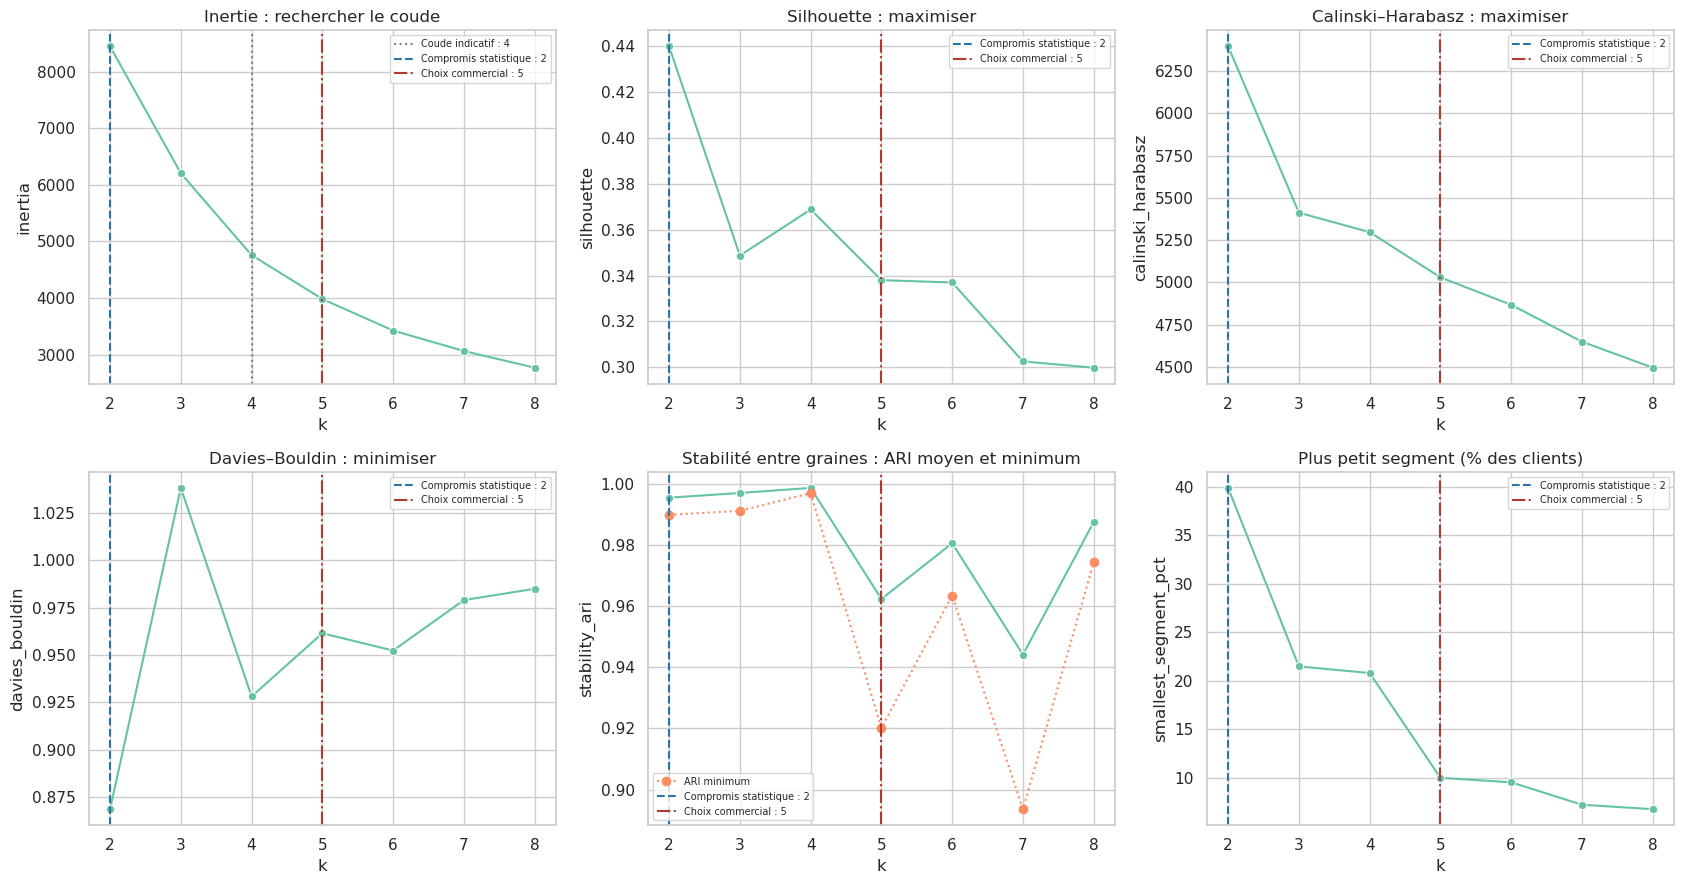

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
plot_specs = [
    ("inertia", "Inertie : rechercher le coude"),
    ("silhouette", "Silhouette : maximiser"),
    ("calinski_harabasz", "Calinski-Harabasz : maximiser"),
    ("davies_bouldin", "Davies-Bouldin : minimiser"),
    ("stability_ari", "Stabilité entre graines : ARI moyen et minimum"),
    ("smallest_segment_pct", "Plus petit segment (% des clients)"),
]
for ax, (metric, title) in zip(axes.flat, plot_specs):
    sns.lineplot(data=k_eval, x="k", y=metric, marker="o", ax=ax)
    if metric == "stability_ari":
        ax.plot(k_eval["k"], k_eval["stability_ari_min"], "o:", label="ARI minimum")
    if metric == "inertia":
        ax.axvline(ELBOW_K, color="gray", linestyle=":", label=f"Coude indicatif : {ELBOW_K}")
    ax.axvline(STATISTICAL_K, color="#2874A6", linestyle="--", label=f"Compromis statistique : {STATISTICAL_K}")
    ax.axvline(FINAL_K, color="#B03A2E", linestyle="-.", label=f"Choix commercial : {FINAL_K}")
    ax.set_title(title)
    ax.set_xticks(K_VALUES)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

,k,inertia,silhouette,calinski_harabasz,davies_bouldin,stability_ari,stability_ari_min,smallest_segment_n,smallest_segment_pct,inertia_gain_pct,elbow_distance,rank_silhouette,rank_calinski_harabasz,rank_davies_bouldin,mean_metric_rank
0,2,8443.18,0.44,6396.33,0.87,1.00,0.99,2346,39.91,NaN,0.00,1.00,1.00,1.00,1.00
2,4,4759.29,0.37,5296.73,0.93,1.00,1.00,1223,20.81,23.29,0.32,2.00,3.00,2.00,2.33
3,5,3984.88,0.34,5029.11,0.96,0.96,0.92,587,9.99,16.27,0.29,4.00,4.00,4.00,4.00


,k,Cluster,Effectif,Recence_moy_jours,Recence_med_jours,Frequence_moy_factures,Frequence_med_factures,Montant_moy_GBP,Montant_med_GBP,CA_GBP,Pct_clients,Pct_CA
0,2,0,3532,300.30,291.50,2.07,2.00,611.11,416.48,2158452.00,60.09,12.20
1,2,1,2346,52.34,24.00,12.64,8.00,6618.50,2869.74,15527008.64,39.91,87.80
2,4,0,1462,230.42,186.00,5.02,4.00,1970.88,1480.13,2881420.74,24.87,16.29
3,4,1,1959,396.54,404.00,1.37,1.00,319.98,277.93,626841.70,33.33,3.54
4,4,2,1223,27.84,17.00,19.02,13.00,10753.57,5033.77,13151619.31,20.81,74.36
5,4,3,1234,28.91,24.00,2.98,3.00,831.10,725.02,1025578.89,20.99,5.80
6,5,0,587,18.00,8.00,28.56,20.00,17829.92,8497.82,10466163.38,9.99,59.18
7,5,1,1580,416.98,417.00,1.23,1.00,252.15,227.31,398399.52,26.88,2.25
8,5,2,1250,58.36,39.00,8.56,8.00,3412.10,2719.61,4265129.19,21.27,24.12
9,5,3,1126,32.30,28.00,2.50,2.00,683.75,613.24,769902.44,19.16,4.35


Cluster_k5,0,1,2,3,4
Cluster_k4,,,,,
0,0,0,440,13,1009
1,0,1580,0,64,315
2,587,0,636,0,0
3,0,0,174,1049,11


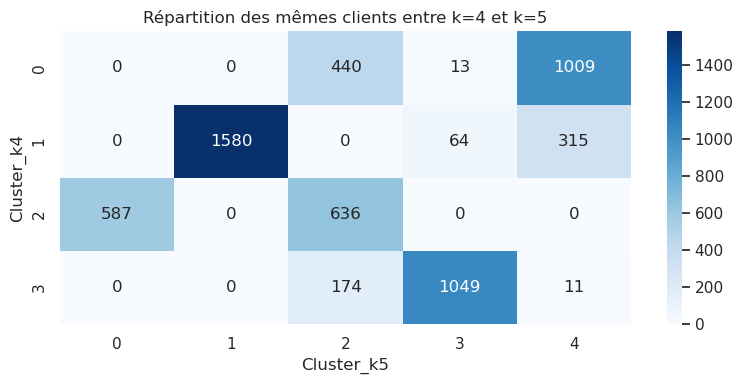

Compromis statistique indicatif : k=2 ; décision commerciale : k=5.
Écart de silhouette (commercial - statistique) : -0.1019
À k=5 : ARI moyen=0.9623, minimum=0.9201 ; plus petit groupe=9.99%.
Ces mesures documentent le compromis ; elles ne prouvent pas un gain commercial.


In [39]:
# Comparer le compromis statistique, k=4 et le choix commercial k=5.
comparison_ks = sorted({STATISTICAL_K, 4, FINAL_K})
profile_frames = []
for k in comparison_ks:
    customer_profiles = rfm.assign(Cluster=candidate_models[k].labels_)
    profile = customer_profiles.groupby("Cluster").agg(
        Effectif=("CustomerID", "size"),
        Recence_moy_jours=("Recency", "mean"),
        Recence_med_jours=("Recency", "median"),
        Frequence_moy_factures=("Frequency", "mean"),
        Frequence_med_factures=("Frequency", "median"),
        Montant_moy_GBP=("Monetary", "mean"),
        Montant_med_GBP=("Monetary", "median"),
        CA_GBP=("Monetary", "sum"),
    ).reset_index()
    profile.insert(0, "k", k)
    profile["Pct_clients"] = profile["Effectif"] / len(rfm) * 100
    profile["Pct_CA"] = profile["CA_GBP"] / rfm["Monetary"].sum() * 100
    profile_frames.append(profile)
candidate_profiles = pd.concat(profile_frames, ignore_index=True)
display(k_eval[k_eval["k"].isin(comparison_ks)])
display(candidate_profiles)

# Les identifiants de clusters sont arbitraires ; ce tableau compte les
# mêmes clients dans les deux partitions, sans supposer un emboîtement.
transitions_4_5 = pd.crosstab(
    pd.Series(candidate_models[4].labels_, name="Cluster_k4"),
    pd.Series(candidate_models[5].labels_, name="Cluster_k5"),
)
display(transitions_4_5)
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(transitions_4_5, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("Répartition des mêmes clients entre k=4 et k=5")
plt.tight_layout()
plt.show()

reference = k_eval.set_index("k").loc[STATISTICAL_K]
commercial = k_eval.set_index("k").loc[FINAL_K]
print(f"Compromis statistique indicatif : k={STATISTICAL_K} ; décision commerciale : k={FINAL_K}.")
print(f"Écart de silhouette (commercial - statistique) : {commercial['silhouette'] - reference['silhouette']:+.4f}")
print(f"À k=5 : ARI moyen={commercial['stability_ari']:.4f}, minimum={commercial['stability_ari_min']:.4f} ; plus petit groupe={commercial['smallest_segment_pct']:.2f}%.")
print("Ces mesures documentent le compromis ; elles ne prouvent pas un gain commercial.")
candidate_profiles.to_csv(OUTPUT_DIR / "profils_k_candidats.csv", index=False)
transitions_4_5.to_csv(OUTPUT_DIR / "comparaison_k4_k5.csv")

### Pourquoi conserver cinq segments pour le marketing ?

Le classement statistique ci-dessus est conservé tel qu'il est calculé, même
s'il privilégie quatre segments ou une autre valeur. **Cinq segments est une
décision commerciale**, à examiner à partir des profils et des croisements
k=4 / k=5 affichés ci-dessus, puis du tableau nommé en partie 4.

L'intérêt recherché est de distinguer des actions différentes : fidélisation
VIP pour les clients à forte valeur, développement des achats des clients
actifs, encouragement au prochain achat des occasionnels récents, réactivation
des clients inactifs avec une valeur historique significative et relance
limitée des inactifs à faible valeur. Ces profils doivent apparaître dans les
résultats ; les noms ne constituent pas une preuve de leur existence.

Pour défendre le cinquième groupe, examiner quels clients sont redistribués,
les écarts de récence, fréquence et montant en unités originales, et si ces
écarts justifient une campagne distincte. K-means n'étant pas hiérarchique,
passer de quatre à cinq groupes peut réorganiser plusieurs segments.

Le coût accepté est une éventuelle baisse des indices internes ou de la
stabilité et une campagne supplémentaire à gérer. L'avantage commercial
reste une **hypothèse à tester**, par exemple en comparant les stratégies à
quatre et cinq segments sur des groupes randomisés, avec un budget et une
pression de contact comparables : marge incrémentale par client, conversion
et désabonnements. Sans différence de profil exploitable ou sans gain mesuré,
il faudra reconsidérer ce choix.

Enfin, un achat récent ne prouve pas qu'un client est nouveau et le montant
des achats ne mesure pas sa rentabilité : ces noms demandent une validation
par l'ancienneté et les marges.

**Lecture de l'exécution vérifiée sur les 5 878 clients :** les trois indices
internes privilégient k=2 ; le coude géométrique indicatif se situe à k=4.
Le groupe à forte valeur de k=4 (1 223 clients, cluster 2 dans cette exécution)
se répartit entre 587 Champions et 636 clients du groupe « Actifs rentables »
à k=5. Ce dernier groupe reçoit aussi des clients d'autres clusters : il ne
s'agit donc pas d'une simple subdivision hiérarchique.

Les Champions représentent 9,99 % des clients et 59,18 % du CA retenu, avec
28,56 factures et 17 829,92 £ d'achats moyens, contre 8,56 factures et
3 412,10 £ pour l'ensemble des Actifs rentables. Cette distinction donne un
argument concret pour séparer une campagne VIP d'une campagne de développement
des achats. Elle ne démontre pas encore un gain de marge.

Le compromis est mesurable : la silhouette passe de 0,3688 à k=4 à 0,3380
à k=5 ; l'ARI moyen entre graines passe de 0,9986 à 0,9623 (minimum 0,9201
à k=5). Le plus petit groupe à k=5 contient 587 clients. Ces chiffres décrivent
cette exécution et doivent être revus si les données ou le prétraitement changent.


In [40]:
# Réutiliser exactement le modèle évalué, pour que les métriques décrivent
# bien la partition finale (mêmes données, graine et n_init).
kmeans = candidate_models[FINAL_K]
rfm_model["Cluster"] = kmeans.labels_
rfm_clustered = rfm.merge(rfm_model[["CustomerID", "Cluster"]], on="CustomerID", how="left")
rfm_clustered["Cluster"] = rfm_clustered["Cluster"].astype(int)
rfm_clustered["Cluster"].value_counts().sort_index().to_frame("effectif")

,effectif
Cluster,
0,587
1,1580
2,1250
3,1126
4,1335


## 5. Partie 4 - Caractérisation et nommage des segments

Les segments sont nommés à partir du profil RFM moyen : récence faible = achat récent, fréquence élevée = engagement, montant élevé = valeur économique.

In [41]:
cluster_profile = (
    rfm_clustered.groupby("Cluster")
    .agg(
        Effectif=("CustomerID", "nunique"),
        Recency_mean=("Recency", "mean"),
        Frequency_mean=("Frequency", "mean"),
        Monetary_mean=("Monetary", "mean"),
        Monetary_total=("Monetary", "sum"),
        AverageBasket_mean=("AverageBasket", "mean"),
        Tenure_mean=("CustomerTenureDays", "mean"),
    )
    .reset_index()
)
cluster_profile["Pct_clients"] = cluster_profile["Effectif"] / cluster_profile["Effectif"].sum() * 100
cluster_profile["Pct_CA"] = cluster_profile["Monetary_total"] / cluster_profile["Monetary_total"].sum() * 100

# Scores métier : plus la récence est basse, meilleur est le score.
profile_ranked = cluster_profile.copy()
profile_ranked["r_score"] = profile_ranked["Recency_mean"].rank(ascending=False)
profile_ranked["f_score"] = profile_ranked["Frequency_mean"].rank(ascending=True)
profile_ranked["m_score"] = profile_ranked["Monetary_mean"].rank(ascending=True)
profile_ranked["rfm_score"] = profile_ranked[["r_score", "f_score", "m_score"]].sum(axis=1)

profile_ranked.sort_values("rfm_score", ascending=False)

,Cluster,Effectif,Recency_mean,Frequency_mean,Monetary_mean,Monetary_total,AverageBasket_mean,Tenure_mean,Pct_clients,Pct_CA,r_score,f_score,m_score,rfm_score
0,0,587,18.00,28.56,17829.92,10466163.38,690.67,654.02,9.99,59.18,5.00,5.00,5.00,15.00
2,2,1250,58.36,8.56,3412.10,4265129.19,445.93,558.36,21.27,24.12,3.00,4.00,4.00,11.00
3,3,1126,32.30,2.50,683.75,769902.44,308.48,244.58,19.16,4.35,4.00,2.00,2.00,8.00
4,4,1335,303.15,3.56,1337.73,1785866.10,474.98,545.26,22.71,10.10,2.00,3.00,3.00,8.00
1,1,1580,416.98,1.23,252.15,398399.52,220.31,446.32,26.88,2.25,1.00,1.00,1.00,3.00


In [42]:
def assign_segment_names(profile):
    # Associe des noms métier uniques aux clusters selon leur position RFM relative.
    # Le score RFM sert de base, puis les arbitrages tiennent compte de la récence
    # et de la valeur historique pour éviter des noms trompeurs.
    p = profile.copy()
    p["segment_name"] = None

    champions_cluster = p.sort_values("rfm_score", ascending=False).iloc[0]["Cluster"]
    p.loc[p["Cluster"] == champions_cluster, "segment_name"] = "Champions"

    sleeping_cluster = p.sort_values("rfm_score", ascending=True).iloc[0]["Cluster"]
    p.loc[p["Cluster"] == sleeping_cluster, "segment_name"] = "Endormis faible valeur"

    remaining = p[p["segment_name"].isna()].copy()
    risk_cluster = remaining.sort_values(["Recency_mean", "Monetary_mean"], ascending=[False, False]).iloc[0]["Cluster"]
    p.loc[p["Cluster"] == risk_cluster, "segment_name"] = "À risque"

    remaining = p[p["segment_name"].isna()].copy()
    active_cluster = remaining.sort_values("Monetary_mean", ascending=False).iloc[0]["Cluster"]
    p.loc[p["Cluster"] == active_cluster, "segment_name"] = "Actifs rentables"

    p.loc[p["segment_name"].isna(), "segment_name"] = "Nouveaux occasionnels"
    return p[["Cluster", "segment_name"]]

segment_names = assign_segment_names(profile_ranked)
rfm_clustered = rfm_clustered.merge(segment_names, on="Cluster", how="left")

segment_names.sort_values("Cluster")

,Cluster,segment_name
0,0,Champions
1,1,Endormis faible valeur
2,2,Actifs rentables
3,3,Nouveaux occasionnels
4,4,À risque


In [43]:
# Ajout du segment au niveau transaction pour caractériser pays et produits.
clean_segmented = clean.merge(rfm_clustered[["CustomerID", "segment_name"]], on="CustomerID", how="left")

def top_values_by_revenue(data, group_col, value_col, n=3):
    revenue = (
        data.groupby([group_col, value_col], dropna=True)["LineAmount"]
        .sum()
        .reset_index()
        .sort_values([group_col, "LineAmount"], ascending=[True, False])
    )
    top = (
        revenue.groupby(group_col)
        .head(n)
        .groupby(group_col)[value_col]
        .apply(lambda s: ", ".join(s.astype(str)))
    )
    return top

top_countries = top_values_by_revenue(clean_segmented, "segment_name", "Country", n=3)
top_products = top_values_by_revenue(clean_segmented, "segment_name", "Description", n=3)

segment_summary = (
    rfm_clustered.groupby("segment_name")
    .agg(
        Effectif=("CustomerID", "nunique"),
        Recence_moy=("Recency", "mean"),
        Frequence_moy=("Frequency", "mean"),
        Montant_moy=("Monetary", "mean"),
        CA_total=("Monetary", "sum"),
        Panier_moy=("AverageBasket", "mean"),
    )
)
segment_summary["Pct_clients"] = segment_summary["Effectif"] / segment_summary["Effectif"].sum() * 100
segment_summary["Pct_CA"] = segment_summary["CA_total"] / segment_summary["CA_total"].sum() * 100
segment_summary["Top pays"] = segment_summary.index.map(top_countries)
segment_summary["Top produits"] = segment_summary.index.map(top_products)

segment_summary = (
    segment_summary
    .reset_index()
    .rename(columns={"segment_name": "Segment"})
    .sort_values("Pct_CA", ascending=False)
)

ordered_cols = ["Segment", "Effectif", "Pct_clients", "Pct_CA", "Recence_moy", "Frequence_moy", "Montant_moy", "Panier_moy", "Top pays", "Top produits"]
segment_summary[ordered_cols]

,Segment,Effectif,Pct_clients,Pct_CA,Recence_moy,Frequence_moy,Montant_moy,Panier_moy,Top pays,Top produits
1,Champions,587,9.99,59.18,18.00,28.56,17829.92,690.67,"United Kingdom, EIRE, Netherlands","REGENCY CAKESTAND 3 TIER, PAPER CRAFT , LITTLE..."
0,Actifs rentables,1250,21.27,24.12,58.36,8.56,3412.10,445.93,"United Kingdom, Germany, France","MEDIUM CERAMIC TOP STORAGE JAR, WHITE HANGING ..."
4,À risque,1335,22.71,10.10,303.15,3.56,1337.73,474.98,"United Kingdom, Germany, Denmark","Manual, WHITE HANGING HEART T-LIGHT HOLDER, RE..."
3,Nouveaux occasionnels,1126,19.16,4.35,32.30,2.50,683.75,308.48,"United Kingdom, Germany, France","POSTAGE, REGENCY CAKESTAND 3 TIER, WHITE HANGI..."
2,Endormis faible valeur,1580,26.88,2.25,416.98,1.23,252.15,220.31,"United Kingdom, France, Germany","WHITE HANGING HEART T-LIGHT HOLDER, REGENCY CA..."


In [44]:
recommendations = {
    "Champions": "Programme VIP, accès anticipé, cadeaux relationnels et demande d'avis/ambassadeurs. Objectif : protéger la valeur et encourager le bouche-à-oreille.",
    "Actifs rentables": "Bundles, seuils de livraison gratuite et recommandations de produits complémentaires. Objectif : consolider une forte valeur déjà récente.",
    "Nouveaux occasionnels": "Coupon de deuxième achat, onboarding court et sélection de best-sellers. Objectif : transformer l'achat récent en habitude.",
    "À risque": "Campagne de réactivation personnalisée avec offre limitée dans le temps. Objectif : récupérer des clients ayant un historique utile mais une récence défavorable.",
    "Endormis faible valeur": "Relance automatisée peu coûteuse, puis réduction de la pression marketing si absence de réponse. Objectif : maîtriser le coût commercial.",
}

recommendations_table = segment_summary[["Segment", "Effectif", "Pct_CA"]].copy()
recommendations_table["Recommandation marketing"] = recommendations_table["Segment"].map(recommendations)
recommendations_table

,Segment,Effectif,Pct_CA,Recommandation marketing
1,Champions,587,59.18,"Programme VIP, accès anticipé, cadeaux relatio..."
0,Actifs rentables,1250,24.12,"Bundles, seuils de livraison gratuite et recom..."
4,À risque,1335,10.10,Campagne de réactivation personnalisée avec of...
3,Nouveaux occasionnels,1126,4.35,"Coupon de deuxième achat, onboarding court et ..."
2,Endormis faible valeur,1580,2.25,"Relance automatisée peu coûteuse, puis réducti..."


### Tableau image des recommandations

Le tableau ci-dessous est généré automatiquement à partir du fichier `outputs/recommandations_segments.csv`. Il peut être intégré directement dans le rapport ou utilisé pendant la présentation orale.


Image générée : outputs/tableau_recommandations.png


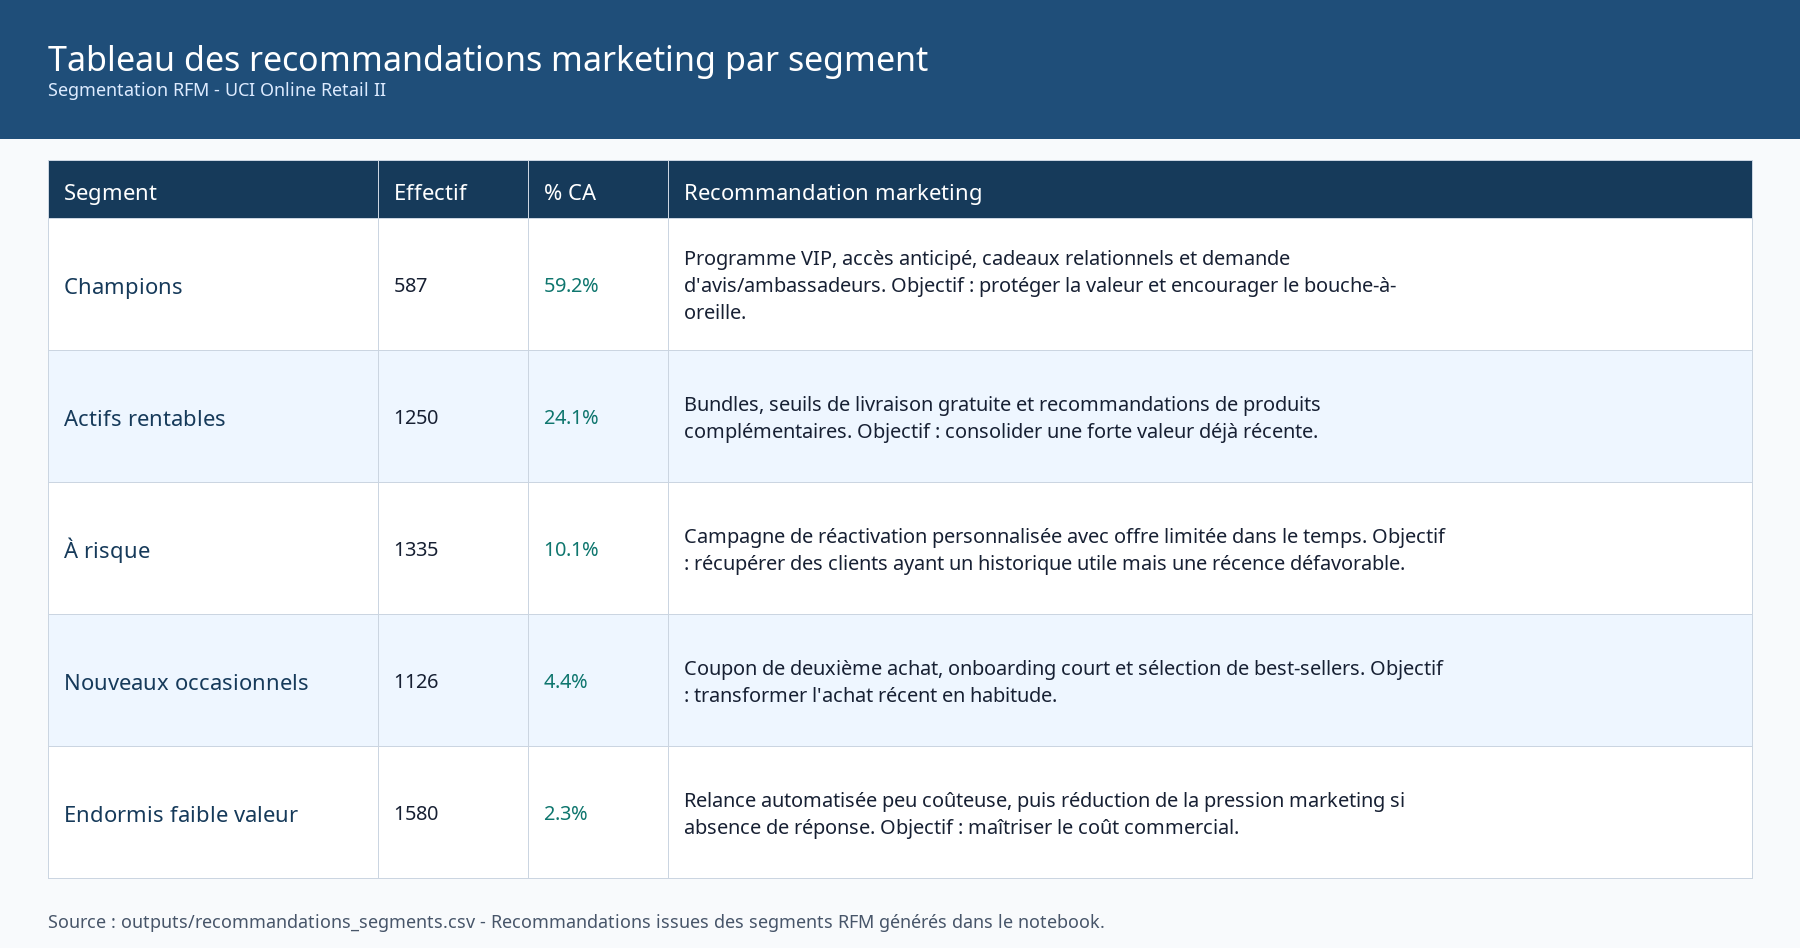

In [45]:
# Génération d'un tableau image pour la présentation.
# L'image est pratique pour intégrer les recommandations dans un support PowerPoint,
# un rapport PDF ou une démonstration orale.
import csv
import subprocess
import textwrap
from PIL import Image, ImageDraw, ImageFont
from IPython.display import Image as DisplayImage, display

recommendation_csv = OUTPUT_DIR / "recommandations_segments.csv"
recommendation_image = OUTPUT_DIR / "tableau_recommandations.png"

recommendations_table.to_csv(recommendation_csv, index=False)

with recommendation_csv.open(newline="", encoding="utf-8") as f:
    rows = list(csv.DictReader(f))


def find_font_path():
    """Retourne une police système compatible avec les accents, si disponible."""
    try:
        result = subprocess.check_output(["fc-match", "-v", "NotoSans-Regular.ttf"], text=True)
        for line in result.splitlines():
            line = line.strip()
            if line.startswith("file:"):
                return line.split('"')[1]
    except Exception:
        return None
    return None

font_file = find_font_path()
font_title = ImageFont.truetype(font_file, 34) if font_file else ImageFont.load_default()
font_header = ImageFont.truetype(font_file, 22) if font_file else ImageFont.load_default()
font_body = ImageFont.truetype(font_file, 20) if font_file else ImageFont.load_default()
font_small = ImageFont.truetype(font_file, 18) if font_file else ImageFont.load_default()

width = 1800
margin = 48
title_height = 90
header_height = 58
row_height = 132
footer_height = 44
height = margin * 2 + title_height + header_height + row_height * len(rows) + footer_height

image = Image.new("RGB", (width, height), "#F8FAFC")
draw = ImageDraw.Draw(image)

blue = "#1F4E79"
blue_dark = "#163A5A"
grid = "#CBD5E1"
text = "#172033"
muted = "#475569"
white = "#FFFFFF"
row_alt = "#EEF6FF"
green = "#0F766E"

draw.rectangle([0, 0, width, margin + title_height], fill=blue)
draw.text((margin, 34), "Tableau des recommandations marketing par segment", fill=white, font=font_title)
draw.text((margin, 76), "Segmentation RFM - UCI Online Retail II", fill="#DDEBFF", font=font_small)

x0 = margin
y = margin + title_height + 22
column_widths = [330, 150, 140, width - 2 * margin - 330 - 150 - 140]
headers = ["Segment", "Effectif", "% CA", "Recommandation marketing"]

x = x0
for header, col_width in zip(headers, column_widths):
    draw.rectangle([x, y, x + col_width, y + header_height], fill=blue_dark, outline=grid)
    draw.text((x + 16, y + 16), header, fill=white, font=font_header)
    x += col_width

y += header_height
for index, row in enumerate(rows):
    fill = white if index % 2 == 0 else row_alt
    draw.rectangle([x0, y, width - margin, y + row_height], fill=fill, outline=grid)

    pct_ca = f"{float(row['Pct_CA']):.1f}%"
    values = [row["Segment"], row["Effectif"], pct_ca, row["Recommandation marketing"]]
    wraps = [22, 9, 8, 82]
    fonts = [font_header, font_body, font_body, font_body]
    colors = [blue_dark, text, green, text]

    x = x0
    for value, col_width, wrap, font, color in zip(values, column_widths, wraps, fonts, colors):
        draw.rectangle([x, y, x + col_width, y + row_height], outline=grid)
        lines = textwrap.wrap(str(value), width=wrap, break_long_words=False)
        line_height = 27
        start_y = y + max(14, (row_height - line_height * len(lines)) // 2)
        for line_index, line in enumerate(lines[:4]):
            draw.text((x + 16, start_y + line_index * line_height), line, fill=color, font=font)
        x += col_width
    y += row_height

footer = "Source : outputs/recommandations_segments.csv - Recommandations issues des segments RFM générés dans le notebook."
draw.text((margin, height - margin + 8), footer, fill=muted, font=font_small)

image.save(recommendation_image, quality=95)
print(f"Image générée : {recommendation_image}")
display(DisplayImage(filename=str(recommendation_image)))

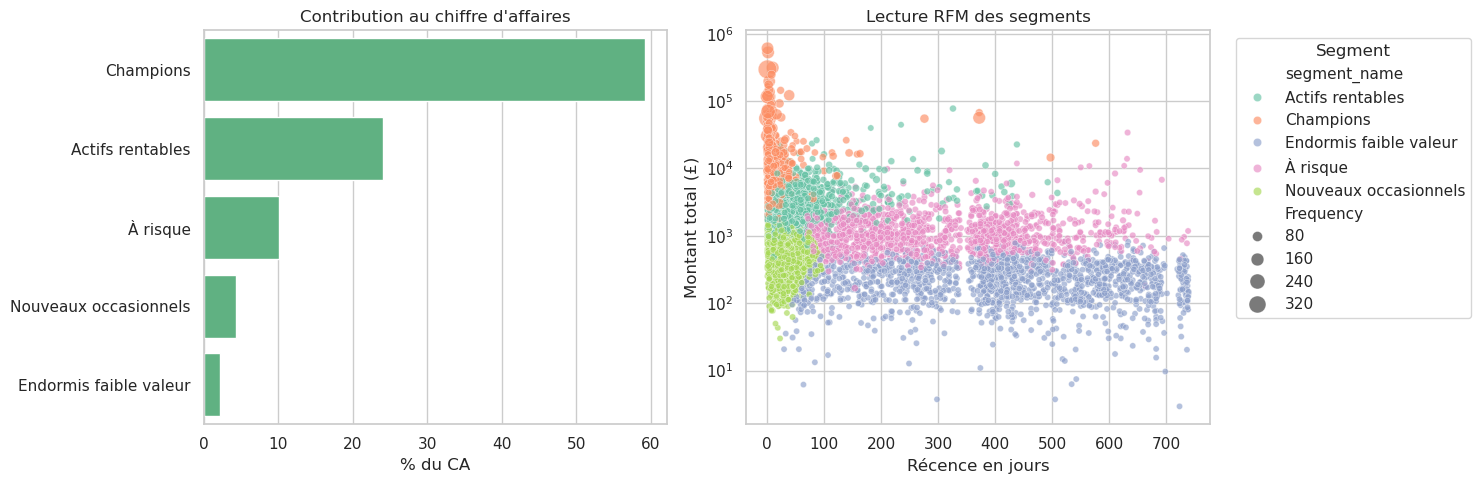

In [46]:
# Visualisations finales pour le rapport.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=segment_summary, y="Segment", x="Pct_CA", ax=axes[0], color="#52BE80")
axes[0].set_title("Contribution au chiffre d'affaires")
axes[0].set_xlabel("% du CA")
axes[0].set_ylabel("")

sns.scatterplot(
    data=rfm_clustered,
    x="Recency",
    y="Monetary",
    hue="segment_name",
    size="Frequency",
    sizes=(20, 180),
    alpha=0.65,
    ax=axes[1],
)
axes[1].set_title("Lecture RFM des segments")
axes[1].set_xlabel("Récence en jours")
axes[1].set_ylabel("Montant total (£)")
axes[1].set_yscale("log")
axes[1].legend(title="Segment", bbox_to_anchor=(1.04, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [47]:
# Sauvegarde des livrables exploitables.
rfm_clustered.to_csv(OUTPUT_DIR / "rfm_clients_segments.csv", index=False)
segment_summary[ordered_cols].to_csv(OUTPUT_DIR / "tableau_synthese_segments.csv", index=False)
recommendations_table.to_csv(OUTPUT_DIR / "recommandations_segments.csv", index=False)

print("Fichiers générés :")
for path in sorted(OUTPUT_DIR.glob("*.csv")):
    print("-", path)

Fichiers générés :
- outputs/audit_retours.csv
- outputs/choix_k.csv
- outputs/comparaison_k4_k5.csv
- outputs/evaluation_k.csv
- outputs/migrations_retours.csv
- outputs/profils_k_candidats.csv
- outputs/profils_politiques_retours.csv
- outputs/recommandations_segments.csv
- outputs/retours_par_segment.csv
- outputs/rfm_clients_segments.csv
- outputs/sensibilite_retours.csv
- outputs/stabilite_sensibilite_retours.csv
- outputs/tableau_synthese_segments.csv


## 6. Partie 5 - Discussion critique et éthique

### Annulations et retours : vérification mesurée

Nous comparons deux politiques sur **les mêmes clients ayant au moins un achat
valide**, dans la fenêtre allant du premier au dernier achat retenu, avec la
même date de référence RFM et **k=5** :

- **Achats positifs** : segmentation principale ; les retours sont exclus du montant.
- **Montant net** : montant des achats diminué des lignes à quantité négative et
  prix strictement positif, avec client et date valides. Ces lignes peuvent porter
  ou non le préfixe `C`. Une annulation à quantité positive est ambiguë : elle est
  comptée dans l'audit, mais nous ne lui inventons pas un montant négatif.

La déduplication reste celle du nettoyage principal. Les clients ayant uniquement
des retours sont comptés séparément et exclus des deux partitions comparées,
car leur récence/fréquence d'achat ne sont pas définies dans cette fenêtre.
Récence et fréquence restent celles des achats valides, y compris les factures
qui pourraient avoir été entièrement retournées : cette expérience isole
**l'effet monétaire**, sans reconstituer les achats nets facture par facture.

Les plafonds au 99e percentile et le `StandardScaler` appris sur les achats
restent **gelés**. Pour M, nous utilisons `sign(M) * log1p(abs(M))`, identique à
`log1p(M)` pour M positif, mais défini aussi pour les montants nets nuls ou
négatifs. Aucune suppression ou remise à zéro de ces clients n'est appliquée.
Les résidus numériques de valeur absolue inférieure ou égale à `1e-8 £` sont
ramenés à zéro pour le comptage des montants nuls. Le modèle K-means est réentraîné sur la variante nette, avec les mêmes paramètres.
Il s'agit d'une sensibilité à prétraitement fixé, pas d'une optimisation complète
d'un nouveau pipeline net.

L'[ARI](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html)
compare les partitions sans dépendre des numéros de clusters. Pour les migrations,
nous utilisons un [appariement optimal des groupes](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.linear_sum_assignment.html)
maximisant le nombre de clients communs. Les noms de la variante nette servent
uniquement de repères d'alignement ; ils ne valident pas ses profils métier.

In [48]:
# Reprendre les mêmes règles de qualité et le même périmètre d'observation.
return_window_start = clean["InvoiceDate"].min()
return_window_end = clean["InvoiceDate"].max()
return_ledger = (
    transactions.drop_duplicates()
    .loc[lambda d: d["CustomerID"].notna() & d["InvoiceDate"].notna()]
    .loc[lambda d: d["InvoiceDate"].between(return_window_start, return_window_end)]
    .loc[lambda d: d["UnitPrice"] > 0]
    .copy()
)
return_ledger["CustomerID"] = return_ledger["CustomerID"].astype(int).astype(str)
credit_lines = return_ledger.loc[return_ledger["Quantity"] < 0].copy()
ambiguous_cancellations = return_ledger.loc[
    return_ledger["is_cancelled_invoice"] & (return_ledger["Quantity"] > 0)
]
common_ids = rfm["CustomerID"]
assert common_ids.is_unique
credits_common = credit_lines.loc[credit_lines["CustomerID"].isin(common_ids)]
credits_only = credit_lines.loc[~credit_lines["CustomerID"].isin(common_ids)]
credit_amounts = credits_common.groupby("CustomerID")["LineAmount"].sum()

returns_rfm = rfm[["CustomerID", "Recency", "Frequency", "Monetary"]].copy()
returns_rfm = returns_rfm.rename(columns={"Monetary": "Monetary_gross"})
returns_rfm["Returns_GBP"] = -returns_rfm["CustomerID"].map(credit_amounts).fillna(0)
returns_rfm["Monetary_net"] = returns_rfm["Monetary_gross"] - returns_rfm["Returns_GBP"]
# Neutraliser uniquement les résidus d'arrondi flottant proches de zéro.
returns_rfm.loc[np.isclose(returns_rfm["Monetary_net"], 0, atol=1e-8, rtol=0), "Monetary_net"] = 0.0
assert (returns_rfm["Returns_GBP"] >= 0).all()
np.testing.assert_allclose(
    returns_rfm["Monetary_net"].sum(),
    returns_rfm["Monetary_gross"].sum() + credits_common["LineAmount"].sum(),
)

returns_audit = pd.DataFrame([{
    "window_start": return_window_start,
    "window_end": return_window_end,
    "reference_date": analysis_date,
    "common_clients": len(returns_rfm),
    "clients_with_returns": int((returns_rfm["Returns_GBP"] > 0).sum()),
    "return_lines_common": len(credits_common),
    "return_lines_without_C_common": int((~credits_common["is_cancelled_invoice"]).sum()),
    "return_only_clients_excluded": credits_only["CustomerID"].nunique(),
    "return_only_amount_GBP_excluded": -credits_only["LineAmount"].sum(),
    "positive_C_lines_excluded": len(ambiguous_cancellations),
    "gross_amount_GBP": returns_rfm["Monetary_gross"].sum(),
    "returns_GBP": returns_rfm["Returns_GBP"].sum(),
    "returns_pct_gross": 100 * returns_rfm["Returns_GBP"].sum() / returns_rfm["Monetary_gross"].sum(),
    "net_amount_GBP": returns_rfm["Monetary_net"].sum(),
    "clients_net_zero": int((returns_rfm["Monetary_net"] == 0).sum()),
    "clients_net_negative": int((returns_rfm["Monetary_net"] < 0).sum()),
}])
display(returns_audit.T.rename(columns={0: "Valeur"}))
returns_audit.to_csv(OUTPUT_DIR / "audit_retours.csv", index=False)

,Valeur
window_start,2009-12-01 07:45:00
window_end,2011-12-09 12:50:00
reference_date,2011-12-10 12:50:00
common_clients,5878
clients_with_returns,2511
return_lines_common,18559
return_lines_without_C_common,0
return_only_clients_excluded,61
return_only_amount_GBP_excluded,61050.92
positive_C_lines_excluded,0


,k,seed,n_init,common_clients,ari,smallest_net_group_n,smallest_net_group_nonpositive_n,migrated_clients,migrated_pct,migrated_with_returns,migrated_without_returns
0,5,42,100,5878,0.58,42,41,1671,28.43,1087,584


,Clients,Clients_avec_retours,Retours_GBP,Clients_migres,Pct_migration
Segment_gross,,,,,
Actifs rentables,1250,847,294487.42,629,50.32
Champions,587,537,571411.63,586,99.83
Endormis faible valeur,1580,247,13293.73,24,1.52
Nouveaux occasionnels,1126,291,15734.23,92,8.17
À risque,1335,589,136089.70,340,25.47


,Politique,Repere_groupe,Clients,Recence_moy,Frequence_moy,Montant_brut_moy_GBP,Montant_net_moy_GBP,Montant_net_median_GBP
0,Achats positifs,Actifs rentables,1250,58.36,8.56,3412.10,3176.51,2595.47
1,Achats positifs,Champions,587,18.00,28.56,17829.92,16856.48,8134.12
2,Achats positifs,Endormis faible valeur,1580,416.98,1.23,252.15,243.74,221.47
3,Achats positifs,Nouveaux occasionnels,1126,32.30,2.50,683.75,669.78,595.92
4,Achats positifs,À risque,1335,303.15,3.56,1337.73,1235.79,986.61
5,Montant net,Actifs rentables,1207,27.63,19.18,10651.89,10273.49,4958.34
6,Montant net,Champions,42,375.69,1.88,7659.29,-787.44,-5.77
7,Montant net,Endormis faible valeur,1951,394.79,1.39,324.90,314.84,267.90
8,Montant net,Nouveaux occasionnels,1228,28.29,3.03,845.25,827.71,717.68
9,Montant net,À risque,1450,227.13,5.04,1955.24,1832.23,1436.19


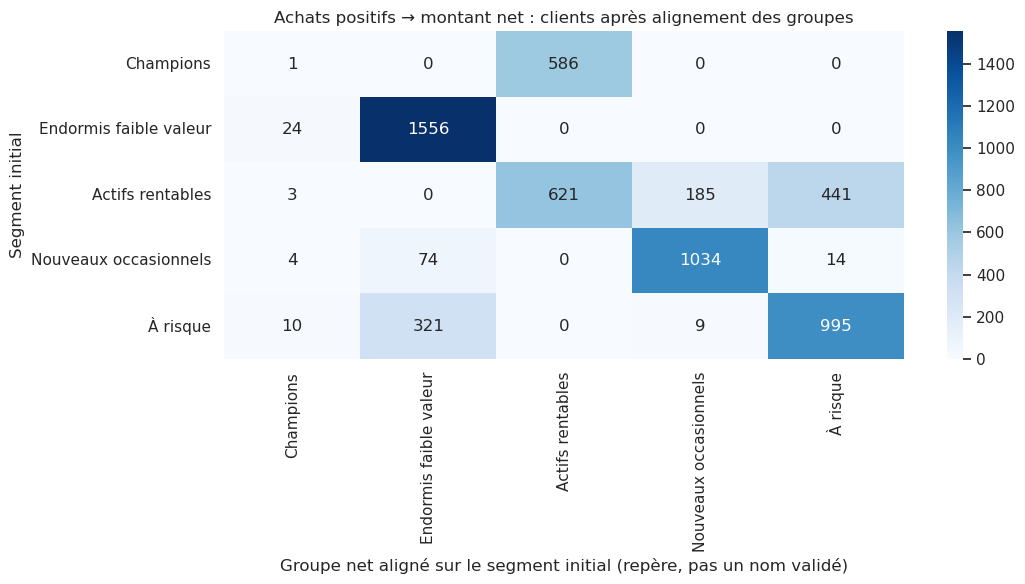

In [49]:
from scipy.optimize import linear_sum_assignment


def signed_log1p(values):
    return np.sign(values) * np.log1p(np.abs(values))


def align_return_clusters(reference_labels, alternative_labels, k):
    counts = pd.crosstab(
        pd.Series(reference_labels), pd.Series(alternative_labels)
    ).reindex(index=range(k), columns=range(k), fill_value=0)
    rows, cols = linear_sum_assignment(counts.to_numpy(), maximize=True)
    mapping = dict(zip(cols, rows))
    aligned = np.array([mapping[label] for label in alternative_labels])
    return aligned


# Reproduire X pour les achats, puis ne modifier que M.
return_caps = rfm[["Recency", "Frequency", "Monetary"]].quantile(0.99)
positive_log = pd.DataFrame(index=rfm.index)
net_log = pd.DataFrame(index=rfm.index)
for col in ["Recency", "Frequency", "Monetary"]:
    positive_values = rfm[col].clip(upper=return_caps[col])
    net_values = returns_rfm["Monetary_net"] if col == "Monetary" else rfm[col]
    net_values = net_values.clip(upper=return_caps[col])
    positive_log[f"log_{col}"] = signed_log1p(positive_values)
    net_log[f"log_{col}"] = signed_log1p(net_values)
np.testing.assert_allclose(scaler.transform(positive_log[feature_cols]), X)
X_returns_net = scaler.transform(net_log[feature_cols])
assert np.isfinite(X_returns_net).all()
assert returns_rfm["CustomerID"].equals(rfm_model["CustomerID"])

return_net_model = KMeans(
    n_clusters=FINAL_K, random_state=RANDOM_STATE, n_init=KMEANS_N_INIT
)
return_net_labels = return_net_model.fit_predict(X_returns_net)
return_gross_labels = kmeans.labels_
return_aligned_labels = align_return_clusters(return_gross_labels, return_net_labels, FINAL_K)
returns_rfm["Changed"] = return_gross_labels != return_aligned_labels
name_by_cluster = segment_names.set_index("Cluster")["segment_name"].to_dict()
returns_rfm["Segment_gross"] = pd.Series(return_gross_labels).map(name_by_cluster).to_numpy()
returns_rfm["Group_net_aligned"] = pd.Series(return_aligned_labels).map(name_by_cluster).to_numpy()
returns_ari = adjusted_rand_score(return_gross_labels, return_net_labels)
returns_changed_n = int(returns_rfm["Changed"].sum())
returns_changed_pct = 100 * returns_rfm["Changed"].mean()

net_group_sizes = pd.Series(return_net_labels).value_counts()
smallest_net_group = net_group_sizes.idxmin()
smallest_net_mask = return_net_labels == smallest_net_group
smallest_net_size = int(smallest_net_mask.sum())
smallest_net_nonpositive = int((returns_rfm.loc[smallest_net_mask, "Monetary_net"] <= 0).sum())
returns_comparison = pd.DataFrame([{
    "k": FINAL_K, "seed": RANDOM_STATE, "n_init": KMEANS_N_INIT,
    "common_clients": len(returns_rfm), "ari": returns_ari,
    "smallest_net_group_n": smallest_net_size,
    "smallest_net_group_nonpositive_n": smallest_net_nonpositive,
    "migrated_clients": returns_changed_n, "migrated_pct": returns_changed_pct,
    "migrated_with_returns": int((returns_rfm["Changed"] & (returns_rfm["Returns_GBP"] > 0)).sum()),
    "migrated_without_returns": int((returns_rfm["Changed"] & (returns_rfm["Returns_GBP"] == 0)).sum()),
}])
return_group_order = [name_by_cluster[i] for i in range(FINAL_K)]
returns_migrations = pd.crosstab(
    returns_rfm["Segment_gross"], returns_rfm["Group_net_aligned"]
).reindex(index=return_group_order, columns=return_group_order, fill_value=0)
assert returns_migrations.to_numpy().sum() == len(rfm)
assert np.trace(returns_migrations.to_numpy()) + returns_changed_n == len(rfm)
returns_by_segment = returns_rfm.groupby("Segment_gross").agg(
    Clients=("CustomerID", "size"),
    Clients_avec_retours=("Returns_GBP", lambda s: int((s > 0).sum())),
    Retours_GBP=("Returns_GBP", "sum"),
    Clients_migres=("Changed", "sum"),
    Pct_migration=("Changed", lambda s: 100 * s.mean()),
)

# Comparer les profils dans les unités originales, sans renommer les groupes nets.
return_profiles = []
for policy, group_col in [("Achats positifs", "Segment_gross"), ("Montant net", "Group_net_aligned")]:
    profile = returns_rfm.groupby(group_col).agg(
        Clients=("CustomerID", "size"), Recence_moy=("Recency", "mean"),
        Frequence_moy=("Frequency", "mean"), Montant_brut_moy_GBP=("Monetary_gross", "mean"),
        Montant_net_moy_GBP=("Monetary_net", "mean"),
        Montant_net_median_GBP=("Monetary_net", "median"),
    ).rename_axis("Repere_groupe").reset_index()
    profile.insert(0, "Politique", policy)
    return_profiles.append(profile)
returns_profiles = pd.concat(return_profiles, ignore_index=True)
display(returns_comparison)
display(returns_by_segment)
display(returns_profiles)
fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(returns_migrations, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("Achats positifs → montant net : clients après alignement des groupes")
ax.set_xlabel("Groupe net aligné sur le segment initial (repère, pas un nom validé)")
ax.set_ylabel("Segment initial")
plt.tight_layout()
plt.show()
returns_comparison.to_csv(OUTPUT_DIR / "sensibilite_retours.csv", index=False)
returns_migrations.to_csv(OUTPUT_DIR / "migrations_retours.csv")
returns_by_segment.to_csv(OUTPUT_DIR / "retours_par_segment.csv")
returns_profiles.to_csv(OUTPUT_DIR / "profils_politiques_retours.csv", index=False)

In [50]:
# Vérifier que le constat ne dépend pas uniquement de la graine 42.
# Mêmes dix graines et n_init=100 pour chaque politique, prétraitement gelé.
return_seed_rows = []
for seed in STABILITY_SEEDS:
    gross_seed = KMeans(n_clusters=FINAL_K, random_state=seed, n_init=KMEANS_N_INIT).fit_predict(X)
    net_seed = KMeans(n_clusters=FINAL_K, random_state=seed, n_init=KMEANS_N_INIT).fit_predict(X_returns_net)
    net_seed_aligned = align_return_clusters(gross_seed, net_seed, FINAL_K)
    return_seed_rows.append({
        "seed": seed, "n_init": KMEANS_N_INIT,
        "ari_gross_net": adjusted_rand_score(gross_seed, net_seed),
        "migrated_pct": 100 * np.mean(gross_seed != net_seed_aligned),
        "ari_gross_vs_reference_gross": adjusted_rand_score(return_gross_labels, gross_seed),
        "ari_net_vs_reference_net": adjusted_rand_score(return_net_labels, net_seed),
    })
returns_seed_check = pd.DataFrame(return_seed_rows)
display(returns_seed_check)
display(returns_seed_check.drop(columns=["seed", "n_init"]).agg(["min", "mean", "max"]))
returns_seed_check.to_csv(OUTPUT_DIR / "stabilite_sensibilite_retours.csv", index=False)

,seed,n_init,ari_gross_net,migrated_pct,ari_gross_vs_reference_gross,ari_net_vs_reference_net
0,0,100,0.59,26.76,0.97,0.99
1,1,100,0.58,28.43,1.00,1.00
2,2,100,0.58,28.46,0.98,1.00
3,3,100,0.59,28.19,0.98,0.99
4,4,100,0.59,28.07,1.00,0.99
5,5,100,0.58,28.38,1.00,1.00
6,6,100,0.58,28.22,1.00,0.99
7,7,100,0.59,28.21,0.97,0.99
8,8,100,0.59,28.00,1.00,0.99
9,9,100,0.58,28.58,0.98,1.00


,ari_gross_net,migrated_pct,ari_gross_vs_reference_gross,ari_net_vs_reference_net
min,0.58,26.76,0.97,0.99
mean,0.59,28.13,0.99,0.99
max,0.59,28.58,1.00,1.00


In [51]:
from IPython.display import Markdown

# Conclusion recalculée à partir des sorties : pas de chiffres inscrits à la main.
audit = returns_audit.iloc[0]
seed_ari = returns_seed_check["ari_gross_net"]
seed_migration = returns_seed_check["migrated_pct"]
most_affected_segment = returns_by_segment["Pct_migration"].idxmax()
most_affected_pct = returns_by_segment.loc[most_affected_segment, "Pct_migration"]
change_statement = (
    "Les deux politiques ne produisent donc pas exactement la même segmentation."
    if returns_changed_n else
    "Les deux politiques produisent ici la même partition après alignement."
)
control_ari_min = returns_seed_check[[
    "ari_gross_vs_reference_gross", "ari_net_vs_reference_net"
]].min().min()
seed_interpretation = (
    "Dans ces répétitions, les accords entre politiques sont tous inférieurs aux "
    "accords obtenus à politique constante : l'écart observé ne se réduit pas "
    "à la seule variation des initialisations testées."
    if seed_ari.max() < control_ari_min else
    "Les accords entre politiques et les contrôles d'initialisation doivent "
    "être examinés ensemble : on ne peut pas attribuer tout l'écart aux retours."
)
display(Markdown(f"""
#### Conclusion mesurée sur les annulations et retours

Sur **{len(returns_rfm):,} clients communs**, **{int(audit['clients_with_returns']):,}**
ont des retours retenus. Ceux-ci représentent **{audit['returns_GBP']:,.2f} £**,
soit **{audit['returns_pct_gross']:.2f} %** du montant brut des achats.
Nous conservons **{int(audit['clients_net_zero'])} montants nets nuls** et
**{int(audit['clients_net_negative'])} montants nets négatifs**.
Les **{int(audit['return_only_clients_excluded'])} clients ayant seulement des retours**
sont hors de la population comparable.

À k={FINAL_K}, graine {RANDOM_STATE} et n_init={KMEANS_N_INIT}, l'**ARI vaut
{returns_ari:.4f}**. Après appariement optimal, **{returns_changed_n:,} clients
({returns_changed_pct:.2f} %)** changent de groupe. Le segment initial au plus
fort taux de migration est **{most_affected_segment} ({most_affected_pct:.2f} %)**.
{change_statement}

Sur les dix graines supplémentaires, l'ARI achats/net varie de
**{seed_ari.min():.4f} à {seed_ari.max():.4f}** (moyenne **{seed_ari.mean():.4f}**),
et la migration de **{seed_migration.min():.2f} % à {seed_migration.max():.2f} %**.
{seed_interpretation}
Les colonnes de contrôle mesurent séparément les changements d'initialisation
à politique constante. Ces répétitions ne sont ni un intervalle de confiance
ni un test de significativité statistique.

La variante nette contient un plus petit groupe de **{smallest_net_size} clients**,
dont **{smallest_net_nonpositive} ont un montant net nul ou négatif**. Les profils
et la matrice montrent si cette nouvelle population entraîne une réorganisation
des groupes à forte valeur. Avec les paramètres gelés, ces montants peuvent
se situer loin du domaine positif initial : le résultat dépend aussi de cette
géométrie. Un nom de colonne obtenu par appariement n'est pas un nouveau nom
métier ; migrer depuis « Champions » ne signifie pas perdre sa valeur d'achat.

**Portée de la conclusion :** le résultat mesure l'effet de la déduction
monétaire des retours enregistrés, à population, fenêtre, k et prétraitement
fixés. Le réentraînement peut aussi déplacer des clients sans retour, parce
que les centres des groupes changent. Le taux de migration après appariement
ne suffit pas à établir une équivalence commerciale des groupes.

Les retours ne sont pas rapprochés de leurs factures d'origine : certains
peuvent concerner des achats antérieurs à la fenêtre. Une quantité négative
est un indicateur de retour/avoir, pas une preuve de sa nature réelle. Les
annulations ambiguës à quantité positive sont exclues et chiffrées dans l'audit.
Cette expérience n'évalue ni l'effet d'annuler une facture dans F et R, ni une
réoptimisation de k ou du prétraitement pour les montants nets. La segmentation
principale reste celle des achats positifs ; son usage commercial doit tenir
compte des migrations et des profils nets mesurés ici.
"""))


#### Conclusion mesurée sur les annulations et retours

Sur **5,878 clients communs**, **2,511**
ont des retours retenus. Ceux-ci représentent **1,031,016.71 £**,
soit **5.83 %** du montant brut des achats.
Nous conservons **19 montants nets nuls** et
**22 montants nets négatifs**.
Les **61 clients ayant seulement des retours**
sont hors de la population comparable.

À k=5, graine 42 et n_init=100, l'**ARI vaut
0.5810**. Après appariement optimal, **1,671 clients
(28.43 %)** changent de groupe. Le segment initial au plus
fort taux de migration est **Champions (99.83 %)**.
Les deux politiques ne produisent donc pas exactement la même segmentation.

Sur les dix graines supplémentaires, l'ARI achats/net varie de
**0.5806 à 0.5949** (moyenne **0.5858**),
et la migration de **26.76 % à 28.58 %**.
Dans ces répétitions, les accords entre politiques sont tous inférieurs aux accords obtenus à politique constante : l'écart observé ne se réduit pas à la seule variation des initialisations testées.
Les colonnes de contrôle mesurent séparément les changements d'initialisation
à politique constante. Ces répétitions ne sont ni un intervalle de confiance
ni un test de significativité statistique.

La variante nette contient un plus petit groupe de **42 clients**,
dont **41 ont un montant net nul ou négatif**. Les profils
et la matrice montrent si cette nouvelle population entraîne une réorganisation
des groupes à forte valeur. Avec les paramètres gelés, ces montants peuvent
se situer loin du domaine positif initial : le résultat dépend aussi de cette
géométrie. Un nom de colonne obtenu par appariement n'est pas un nouveau nom
métier ; migrer depuis « Champions » ne signifie pas perdre sa valeur d'achat.

**Portée de la conclusion :** le résultat mesure l'effet de la déduction
monétaire des retours enregistrés, à population, fenêtre, k et prétraitement
fixés. Le réentraînement peut aussi déplacer des clients sans retour, parce
que les centres des groupes changent. Le taux de migration après appariement
ne suffit pas à établir une équivalence commerciale des groupes.

Les retours ne sont pas rapprochés de leurs factures d'origine : certains
peuvent concerner des achats antérieurs à la fenêtre. Une quantité négative
est un indicateur de retour/avoir, pas une preuve de sa nature réelle. Les
annulations ambiguës à quantité positive sont exclues et chiffrées dans l'audit.
Cette expérience n'évalue ni l'effet d'annuler une facture dans F et R, ni une
réoptimisation de k ou du prétraitement pour les montants nets. La segmentation
principale reste celle des achats positifs ; son usage commercial doit tenir
compte des migrations et des profils nets mesurés ici.


### Pourquoi ne pas appliquer K-means sur les RFM bruts ?

Les RFM bruts combinent des unités différentes : jours, nombre de factures et livres sterling. Le montant domine mécaniquement la distance euclidienne, et les distributions sont très asymétriques. Le couple `log1p + standardisation` réduit l'effet des extrêmes, rend les variables comparables et produit des clusters plus interprétables.

### Corrélation Fréquence/Montant

Fréquence et montant sont souvent corrélés : un client qui commande souvent dépense généralement plus. Ce n'est pas nécessairement un problème, car les deux variables décrivent deux leviers métier distincts : activité et valeur. Si la redondance devient trop forte, on peut tester une ACP, remplacer `Monetary` par panier moyen, ou comparer la stabilité des segments avec et sans l'une des deux variables.

### Limites du choix de k

La silhouette ne suffit pas : elle favorise parfois des segmentations très simples, peu utiles au marketing. Un bon `k` doit aussi produire des groupes stables, de tailles exploitables et cohérents avec des actions concrètes. La partie 3 affiche les meilleurs k par critère, le compromis de rangs et la comparaison k=4 / k=5. Le choix commercial `k = 5` reste distinct de ces résultats : son intérêt est de permettre des actions différenciées, avec un coût statistique explicitement mesuré et un bénéfice commercial restant à valider.

### Défendre la qualité sans vérité terrain

Sans labels réels, la qualité se défend par triangulation : métriques internes, stabilité, profils RFM distincts, contribution au chiffre d'affaires, cohérence des pays/produits et validation par les équipes marketing. Le segment doit surtout permettre une décision meilleure qu'une campagne uniforme.

### Garde-fous éthiques

La personnalisation ne doit pas devenir discriminatoire ou opaque. Les garde-fous recommandés sont : éviter les prix individualisés injustifiables, documenter les règles d'éligibilité, contrôler les biais géographiques ou socio-économiques, limiter la pression marketing sur les clients vulnérables, mesurer les désabonnements et conserver une option claire de retrait.

## 7. Mini-rapport synthétique et livrables complémentaires

Le rapport synthétique final a été rédigé séparément avec Overleaf. Pour la version mise en forme et prête à déposer, voir le fichier : [Mini rapport synthétique segmentation des clientèles](<../docs/Min Rapport synthetique segmentation des clienteles.pdf>).

Les résultats opérationnels produits par ce notebook sont sauvegardés dans le dossier [outputs](outputs/) :

- `rfm_clients_segments.csv` : base client nettoyée avec les variables RFM et le segment affecté ;
- `tableau_synthese_segments.csv` : tableau de synthèse par segment avec effectif, part de chiffre d'affaires, moyennes RFM, pays et produits principaux ;
- `recommandations_segments.csv` : recommandations marketing associées aux segments ;
- `tableau_recommandations.png` : image du tableau des recommandations, utilisable dans les slides ou le rapport.

Les diagnostics de sélection sont également exportés : `evaluation_k.csv`,
`choix_k.csv`, `profils_k_candidats.csv` et `comparaison_k4_k5.csv`.
L'analyse achats/retours exporte également `audit_retours.csv`,
`sensibilite_retours.csv`, `migrations_retours.csv`, `retours_par_segment.csv`,
`profils_politiques_retours.csv` et `stabilite_sensibilite_retours.csv`.
Le PDF rédigé séparément doit être actualisé avec ces nouvelles analyses avant
remise ; sa présence ne garantit pas qu'il reflète cette version du notebook.

### Rappel de la méthode

Nous avons concaténé les deux feuilles du jeu Online Retail II, nettoyé les transactions bruitées, construit les variables RFM au niveau client, puis appliqué une transformation `log1p` suivie d'une standardisation avant le clustering. Les critères coude, silhouette, Calinski-Harabasz, Davies-Bouldin et stabilité sont comparés sans imposer leur résultat. Le choix commercial final de `k = 5` est distingué du compromis statistique ; les profils k=4 / k=5 permettent d’en discuter l’intérêt pour les segments nommés : Champions, Actifs rentables, À risque, Nouveaux occasionnels et Endormis faible valeur.

### Bonus 3.8 - Interrogation en langage naturel

Pour répondre au bonus proposé dans le sujet, nous avons mis en place une couche expérimentale d'interrogation en langage naturel des résultats. Concrètement, une API développée avec **FastAPI** convertit les fichiers du dossier [outputs](outputs/) en réponses JSON exploitables. Un workflow **n8n** interroge ensuite cette API et répond aux questions marketing du type : « combien de Champions ? », « décris les clients endormis », ou « quelles recommandations pour les clients à risque ? ».

Le workflow utilise une API **DeepSeek** pour formuler les réponses en langage naturel à partir des chiffres exposés par notre API. Nous pourrons présenter ce chatbot le jour de la présentation afin de montrer concrètement comment un responsable marketing peut interroger les résultats sans manipuler directement les fichiers CSV. Cette solution est assumée comme **expérimentale** : elle nous a permis de démontrer l'usage métier d'un assistant conversationnel, même si nous sommes conscients des limites de confidentialité liées à l'envoi potentiel de données vers un service externe. Ce choix a été fait parce que nous ne maîtrisons pas encore suffisamment les méthodes de déploiement de chatbots totalement open source ou auto-hébergés. Dans une version de production, il faudrait privilégier une solution locale ou maîtrisée, anonymiser les données, limiter les champs transmis et documenter clairement les règles de sécurité.

### Limites et garde-fous

Le clustering reste une aide à la décision, pas une vérité terrain. Les segments doivent être suivis dans le temps, validés par les équipes métier et évalués avec des indicateurs de campagne : conversion, désabonnement, panier moyen, satisfaction client et marge. Pour la personnalisation, il faut éviter toute tarification opaque ou discriminatoire, limiter la pression marketing et garantir la transparence sur l'utilisation des données clients.

## 7. Export du modèle pour classer un client
Le fichier JSON conserve les plafonds, les paramètres de standardisation, les centroïdes et les noms de segments. L’API applique ces paramètres figés sans réentraînement. Les données saisies doivent suivre la même définition RFM et une période comparable au jeu historique.


In [ ]:
from export_model import export_model
prediction_model = export_model(
    rfm, scaler, kmeans,
    segment_names.set_index("Cluster")["segment_name"].to_dict(),
    returns_audit.iloc[0], OUTPUT_DIR / "rfm_model.json",
)
print("Modèle exporté :", prediction_model["model_id"])
